In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import keras as kf
from keras.utils import image_dataset_from_directory, to_categorical
from keras.layers import (Conv2D, BatchNormalization, Activation,
                           MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import time
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score,
                              roc_curve, auc)
from sklearn.utils.class_weight import compute_class_weight

In [2]:
import os
import shutil
import random

# Paths
original_dataset = "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"
output_dataset = "split_dataset"

# Split ratios
train_ratio = 0.75
val_ratio = 0.15
test_ratio = 0.10

# Create folders
for split in ["train", "val", "test"]:
    for class_name in os.listdir(original_dataset):
        os.makedirs(os.path.join(output_dataset, split, class_name), exist_ok=True)

# Split process
for class_name in os.listdir(original_dataset):
    class_path = os.path.join(original_dataset, class_name)
    images = os.listdir(class_path)

    random.shuffle(images)

    total = len(images)
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    # Move files
    for img in train_imgs:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(output_dataset, "train", class_name, img))

    for img in val_imgs:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(output_dataset, "val", class_name, img))

    for img in test_imgs:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(output_dataset, "test", class_name, img))

print("Dataset split completed!")

Dataset split completed!


In [3]:
input_shape=(224,224,1)
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 30
DATASET_PATH = "split_dataset" 
SEED=42
AUTOTUNE= tf.data.AUTOTUNE   
np.random.seed(SEED)
tf.random.set_seed(SEED)

train_data = image_dataset_from_directory(
    f"{DATASET_PATH}/train",           
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode="grayscale",
    shuffle=True
)

val_data = image_dataset_from_directory(
    f"{DATASET_PATH}/val",            
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode="grayscale",
    shuffle=False                     
)

test_data = image_dataset_from_directory(
    f"{DATASET_PATH}/test",            
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode="grayscale",
    shuffle=False                      
)

class_names = train_data.class_names
print("Classes:", class_names)   
NUM_CLASSES = len(class_names)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="augmentation")

normalization_layer = tf.keras.layers.Rescaling(1./255)
train_data = (train_data
              .map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
              .cache()
              .prefetch(AUTOTUNE))

val_data = (val_data
            .map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
            .cache()
            .prefetch(AUTOTUNE))

test_data = (test_data
             .map(lambda x, y: (normalization_layer(x), y),   
                  num_parallel_calls=AUTOTUNE)
             .cache()
             .prefetch(AUTOTUNE))
             
all_labels = []
for _, labels in train_data:
    all_labels.extend(np.argmax(labels.numpy(), axis=1))
all_labels = np.array(all_labels)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(all_labels),
    y=all_labels
)
class_weight = dict(enumerate(class_weights))
print("Class weights:", class_weight)

Found 9332 files belonging to 4 classes.
Found 1865 files belonging to 4 classes.
Found 1249 files belonging to 4 classes.
Classes: ['Cyst', 'Normal', 'Stone', 'Tumor']
Class weights: {0: 0.8389068680330817, 1: 0.6128184922511164, 2: 2.260658914728682, 3: 1.362733644859813}


Epoch 1/30
292/292 [==============================] - 61s 201ms/step - loss: 1.1760 - accuracy: 0.5431 - val_loss: 2.7330 - val_accuracy: 0.1099 - lr: 1.0000e-05
Epoch 2/30
292/292 [==============================] - 58s 198ms/step - loss: 0.8122 - accuracy: 0.6848 - val_loss: 2.4187 - val_accuracy: 0.1271 - lr: 1.0000e-05
Epoch 3/30
292/292 [==============================] - 58s 198ms/step - loss: 0.6650 - accuracy: 0.7583 - val_loss: 0.5294 - val_accuracy: 0.8011 - lr: 1.0000e-05
Epoch 4/30
292/292 [==============================] - 58s 198ms/step - loss: 0.5418 - accuracy: 0.8186 - val_loss: 0.4242 - val_accuracy: 0.8772 - lr: 1.0000e-05
Epoch 5/30
292/292 [==============================] - 58s 198ms/step - loss: 0.4409 - accuracy: 0.8653 - val_loss: 0.3157 - val_accuracy: 0.9029 - lr: 1.0000e-05
Epoch 6/30
292/292 [==============================] - 58s 198ms/step - loss: 0.3580 - accuracy: 0.8920 - val_loss: 0.2546 - val_accuracy: 0.9282 - lr: 1.0000e-05
Epoch 7/30
292/292 [========

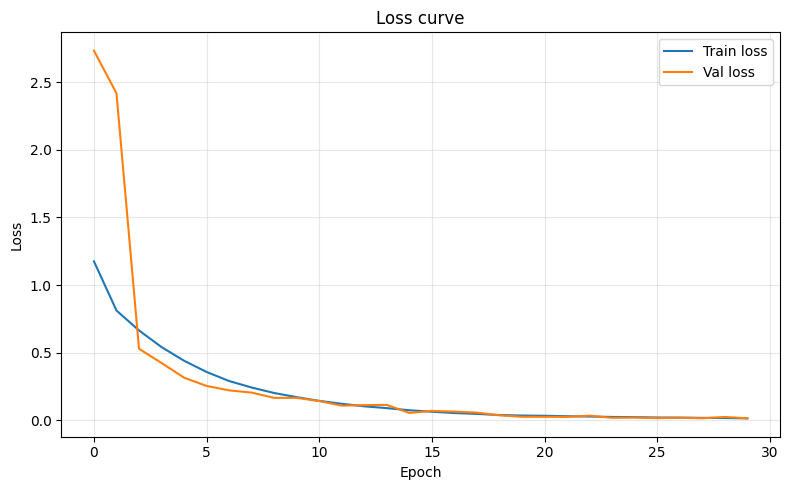

In [6]:
model=kf.Sequential([
    #block 1
    Conv2D(32,(3,3),padding="same",input_shape=input_shape),
    BatchNormalization(),
    Activation("relu"),
    Conv2D(32,(3,3),padding="same"),
    BatchNormalization(),
    Activation("relu"),
    MaxPooling2D(),

    #block 2
    Conv2D(64,(3,3),padding="same"),
    BatchNormalization(),
    Activation("relu"),
    Conv2D(64,(3,3),padding="same"),
    BatchNormalization(),
    Activation("relu"),
    MaxPooling2D(),

    #block 3
    Conv2D(128,(3,3),padding="same"),
    BatchNormalization(),
    Activation("relu"),
    Conv2D(128,(3,3),padding="same"),
    BatchNormalization(),
    Activation("relu"),
    MaxPooling2D(),

    Conv2D(256,(3,3),padding="same"),
    BatchNormalization(),
    Activation("relu"),
    Conv2D(256,(3,3),padding="same"),
    BatchNormalization(),
    Activation("relu"),
    MaxPooling2D(),

    GlobalAveragePooling2D(),
    Dense(256,activation="relu"),
    Dropout(0.3),
    Dense(NUM_CLASSES,activation="softmax")
])
model.compile(
    optimizer=kf.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight
)

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"],     label="Train loss")
plt.plot(history.history["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



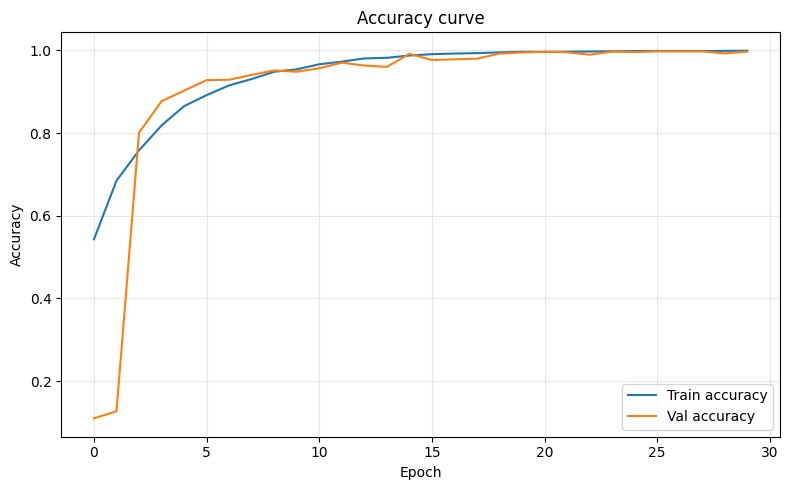

Inference time: 5.64s


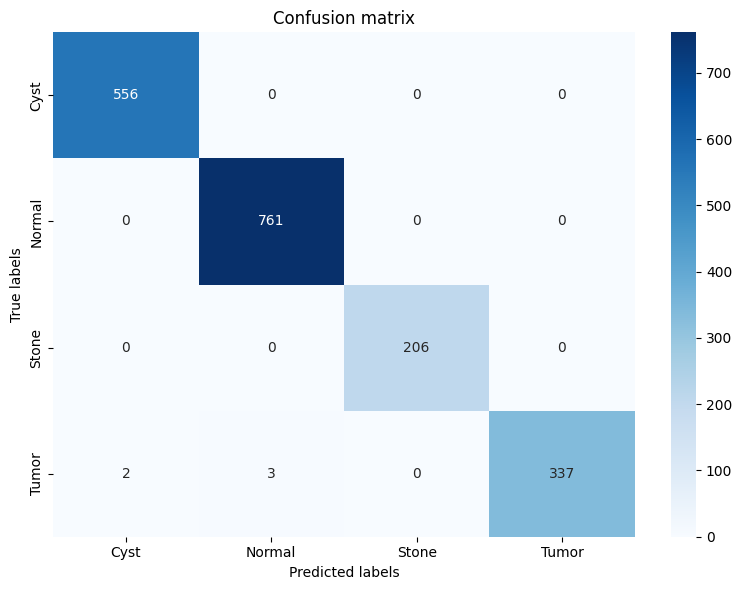


Classification Report:
              precision    recall  f1-score   support

        Cyst       1.00      1.00      1.00       556
      Normal       1.00      1.00      1.00       761
       Stone       1.00      1.00      1.00       206
       Tumor       1.00      0.99      0.99       342

    accuracy                           1.00      1865
   macro avg       1.00      1.00      1.00      1865
weighted avg       1.00      1.00      1.00      1865

Accuracy for 'Cyst': 1.0000
Accuracy for 'Normal': 1.0000
Accuracy for 'Stone': 1.0000
Accuracy for 'Tumor': 0.9854

Overall Accuracy : 99.73%
Precision        : 99.81%
Recall           : 99.63%
F1-Score         : 99.72%


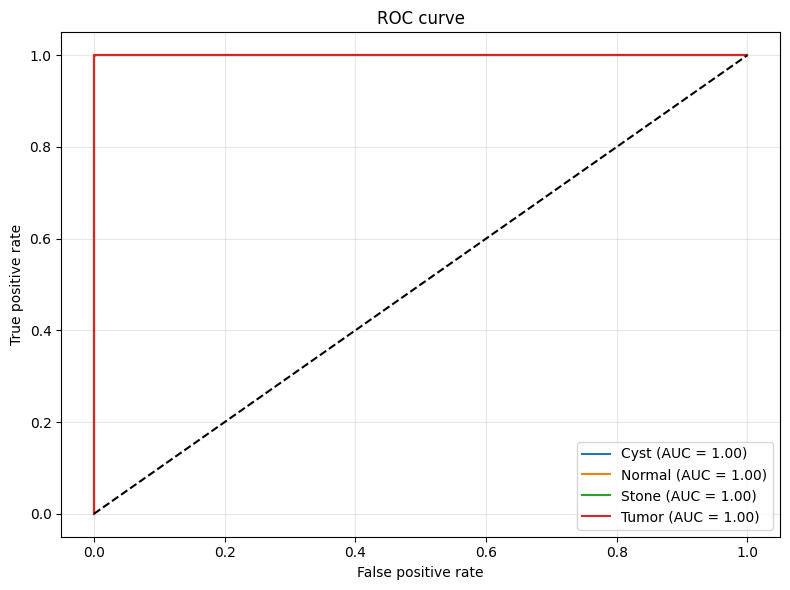


FINAL TEST SET EVALUATION
40/40 [==============================] - 2s 54ms/step - loss: 0.0135 - accuracy: 0.9968

Test Loss:     0.0135
Test Accuracy: 0.9968 (99.68%)


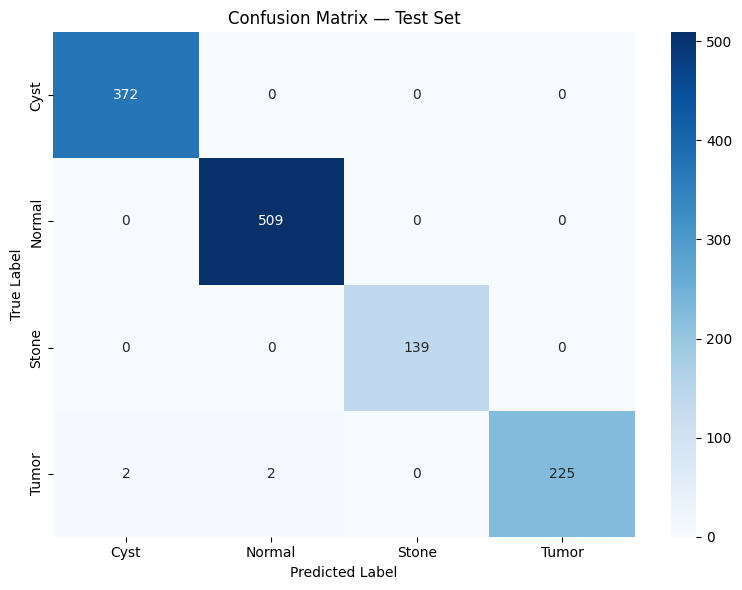


Classification Report:
              precision    recall  f1-score   support

        Cyst       0.99      1.00      1.00       372
      Normal       1.00      1.00      1.00       509
       Stone       1.00      1.00      1.00       139
       Tumor       1.00      0.98      0.99       229

    accuracy                           1.00      1249
   macro avg       1.00      1.00      1.00      1249
weighted avg       1.00      1.00      1.00      1249



In [7]:
#   Accuracy curve  
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"],     label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#   Collect predictions 
start_test_time = time.time()

y_true, y_pred_prob = [], []
for images, labels in val_data:                         
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_prob.extend(preds)

y_true         = np.array(y_true)
y_pred_prob    = np.array(y_pred_prob)
y_pred_classes = np.argmax(y_pred_prob, axis=1)

testing_time = time.time() - start_test_time
print(f"Inference time: {testing_time:.2f}s")

#   Confusion matrix  
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion matrix")
plt.tight_layout()
plt.show()

# ── Classification report ──────────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# ── Per-class accuracy ─────────────────────────────────────────────────
class_accuracy = cm.diagonal() / cm.sum(axis=1)
for i, name in enumerate(class_names):
    print(f"Accuracy for '{name}': {class_accuracy[i]:.4f}")

# ── Overall metrics ────────────────────────────────────────────────────
accuracy  = np.sum(y_pred_classes == y_true) / len(y_true)
precision = precision_score(y_true, y_pred_classes, average="macro")
recall    = recall_score(y_true, y_pred_classes, average="macro")
f1        = f1_score(y_true, y_pred_classes, average="macro")

print(f"\nOverall Accuracy : {accuracy*100:.2f}%")
print(f"Precision        : {precision*100:.2f}%")
print(f"Recall           : {recall*100:.2f}%")
print(f"F1-Score         : {f1*100:.2f}%")

# ── ROC curve ──────────────────────────────────────────────────────────
y_true_onehot = to_categorical(y_true, num_classes=NUM_CLASSES)
plt.figure(figsize=(8, 6))
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC curve")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print("\n" + "="*50)
print("FINAL TEST SET EVALUATION")
print("="*50)
test_loss, test_accuracy = model.evaluate(test_data, verbose=1)
print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# ── Confusion Matrix on Test Set ──────────────────────────────────────────────
y_true, y_pred = [], []

for images, labels in test_data:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix — Test Set")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))